# 位置编码：让模型感知词的顺序

> 上一节，我们用 Embedding 把 token ID 变成了向量。但同一个 token 不管出现在句子的哪个位置，查出的向量完全相同——模型无法区分 "the cat" 和 "cat the"。
>
> 这一节引入 Position Encoding：给每个位置准备一个向量，加到 Token Embedding 上，让同一个 token 在不同位置有不同的表示。我们从零实现正弦位置编码，观察不同频率的波如何为每个位置生成唯一的编码，最后组装出完整的 Transformer 输入层。

正弦位置编码（Sinusoidal Position Encoding）是 Transformer 论文提出的方案。它的核心操作可以概括为：给每个位置计算一组 sin 和 cos 值，不同维度用不同频率的波，然后把算出来的编码直接加到 Token Embedding 上。

这个方案有几个实用的特性：值始终在 [-1, 1] 之间，不会像位置编号那样无限增长；因为是连续函数，训练时没见过的位置也能直接算出编码——这让模型可以处理比训练时更长的序列。利用三角恒等式，不同位置的编码之间还隐含了相对位置关系，模型有可能学到"两个 token 隔了多远"而不仅仅是绝对位置。下面从零实现，配合可视化观察这些波如何为每个位置生成唯一的编码。

In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)
print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.11.0


## 本节要点

通过这一节的学习，以下问题应该能够回答：

1. 为什么 Embedding 之后还需要位置信息？
2. 正弦位置编码的公式是怎样的？为什么用 sin 和 cos？
3. 位置编码是加在 Embedding 上还是拼接？为什么？
4. 正弦位置编码相比可学习的位置编码有什么优势？
5. batch 维度在训练中起什么作用？

## 1. 位置编码

Embedding 解决了"每个 token 是谁"的问题。但语言还需要另一个信息——token 的位置。

同一个 the，出现在句首和句尾，Embedding 查出来的向量完全相同。没有位置信息，模型看到的是两个相同的向量，无法区分 "the cat" 和 "cat the"。

Position Encoding 的思路很直接：给每个位置也准备一个向量，加到 Token Embedding 上。最终的输入向量 = Token Embedding + Position Encoding。同一个 token 在不同位置加上不同的位置编码后，就有了不同的表示。

### 正弦位置编码

给每个位置一个向量，最直接的想法是用位置编号本身——位置 0 是 [0]，位置 1 是 [1]。但这有两个问题：值会无限增长，神经网络更适合处理有界数值；而且训练时只见过短序列，遇到更长序列时模型就不知道怎么处理了。

另一个方案是给每个位置学一个向量（learnable position embedding），和 Token Embedding 一样作为可训练参数。GPT 系列用的就是这种方式。它的局限是只能处理训练时见过的最大长度，无法外推到更长的序列。

Transformer 论文选择了第三种方案：用 sin 和 cos 手工构造。公式如下：

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
```

这个方案有几个特点：

- **值有界**：sin/cos 的输出始终在 [-1, 1] 之间，不会随位置增长发散。
- **可外推**：因为是连续函数，训练时没见过的位置也能直接算出编码。
- **隐含相对位置**：利用三角恒等式，pos+k 的编码可以表示为 pos 编码的线性变换。这让模型有可能学到"两个 token 之间的距离"，而不仅仅是各自的绝对位置。

直观理解：每个维度是一条不同频率的波。低频波（波长长）传递远距离位置关系，高频波（波长短）区分相邻位置的差异。不同频率组合起来，给每个位置生成一个独特的向量。下面直接实现并画出来。

In [4]:
def get_sinusoidal_encoding(seq_len, d_model):
    """
    正弦位置编码：每个位置用不同频率的 sin/cos 波生成唯一向量
    
    PE(pos, 2i)   = sin(pos / 10000^(2i/d))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
    """
    position = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)   # 偶数维 sin
    pe[:, 1::2] = torch.cos(position * div_term)   # 奇数维 cos
    return pe

# 生成 10 个位置、8 维的编码
pe = get_sinusoidal_encoding(seq_len=10, d_model=8)
print(f"位置编码形状: {pe.shape}  ← 10 个位置 × 每个位置 8 维")
print(f"前 3 个位置的编码:\n{pe[:3]}")

位置编码形状: torch.Size([10, 8])  ← 10 个位置 × 每个位置 8 维
前 3 个位置的编码:
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00]])


**看图：位置编码长什么样**

文字不如图直观。下面把不同位置、不同维度的编码画出来，观察它是不是像一组不同频率的波。

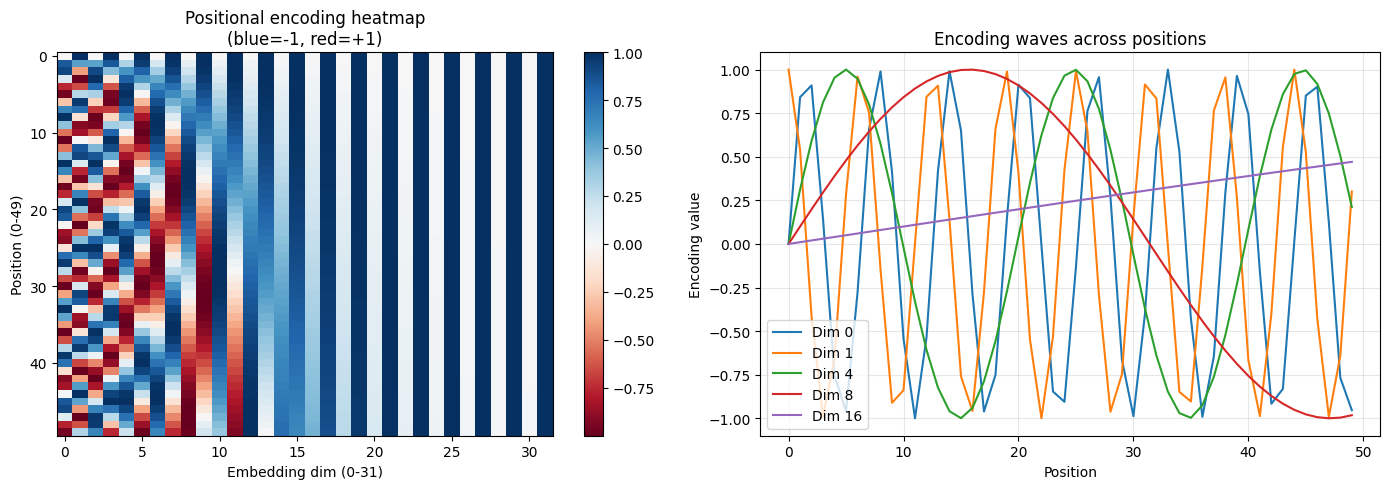

In [5]:
# 可视化位置编码：热力图 + 波形图
pe_viz = get_sinusoidal_encoding(seq_len=50, d_model=32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 热力图 — 横轴=维度, 纵轴=位置, 色=值
im = axes[0].imshow(pe_viz.numpy(), aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Embedding dim (0-31)'); axes[0].set_ylabel('Position (0-49)')
axes[0].set_title('Positional encoding heatmap\n(blue=-1, red=+1)')
plt.colorbar(im, ax=axes[0])

# 右: 选几个维度，看它们的值随位置怎么变
# 低维度波长短（变化快→区分邻居），高维度波长长（变化慢→区分远处）
for dim_idx in [0, 1, 4, 8, 16]:
    axes[1].plot(range(50), pe_viz[:, dim_idx].numpy(), label=f'Dim {dim_idx}')
axes[1].set_xlabel('Position'); axes[1].set_ylabel('Encoding value')
axes[1].set_title('Encoding waves across positions')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. 组装：Token Embedding + Position Encoding

现在把 Token Embedding 和 Position Encoding 合在一起，做成一个 PyTorch Module。

输入是 token ID：`[batch_size, seq_len]`

输出是向量：`[batch_size, seq_len, embed_dim]`

每个样本的每个位置都有一个向量。

In [ ]:
class TokenEmbedding(nn.Module):
    """Token ID → 向量：Embedding 查表 + 位置编码"""
    
    def __init__(self, vocab_size, d_model, max_seq_len=512):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Position Encoding 手工算，不参与训练（register_buffer）
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: [batch, seq_len] → output: [batch, seq_len, d_model]
        seq_len = x.shape[1]
        token_vecs = self.token_emb(x)         # 查表
        pos_vecs = self.pe[:seq_len, :]        # 取对应位置编码
        return token_vecs + pos_vecs            # 加法（不是拼接）

# 测试：用固定输入，确保同一个 token 出现在不同位置
test_vocab_size, test_d_model = 20, 8
emb_module = TokenEmbedding(test_vocab_size, test_d_model)

# token 0 同时出现在位置 0 和位置 3
test_input = torch.tensor([
    [0, 1, 2, 0, 3],   # 同一个 token(0) 在位置 0 和位置 3
    [5, 4, 0, 6, 0],   # 同一个 token(0) 在位置 2 和位置 4
])
output = emb_module(test_input)

print(f"输入:\n{test_input}")
print(f"输出形状: {output.shape}  → [batch=2, seq_len=5, d_model={test_d_model}]")

# 验证：batch 0 中，位置 0 和位置 3 都是 token 0
tid_0 = test_input[0, 0].item()
tid_3 = test_input[0, 3].item()
print(f"\n位置 0 的 token ID = {tid_0}，位置 3 的 token ID = {tid_3}")
print(f"同一个 token，但加了不同位置编码后：")
print(f"  位置 0: {output[0, 0, :3].tolist()}")
print(f"  位置 3: {output[0, 3, :3].tolist()}")
print(f"  → 不同！位置编码让同一个 token 在不同位置有了不同的表示")

**为什么用加法而不是拼接**

把 token 向量和 position 向量相加，而不是拼接，主要有两个原因：

1. 拼接会让维度翻倍，后面每一层的计算量都更大。
2. 加法后面的线性层可以同时利用 token 信息和位置信息——它学到的是两者的组合。

因此标准 Transformer 直接相加。

**附录：Embedding 的缩放惯例**

原始 Transformer 论文在查表之后还会乘以 $\sqrt{d\_model}$：

```python
embedding_output = self.token_emb(x) * math.sqrt(d_model)
```

这样做的原因和 Attention 里的缩放类似：nn.Embedding 的默认初始化标准差约为 1，当 $d\_model$ 较大时（比如 512），Embedding 向量的模长大约是 $\sqrt{d\_model}$。而位置编码的模长也在 $\sqrt{d\_model}$ 附近。如果不缩放，直接相加后两者量级相当；乘以 $\sqrt{d\_model}$ 之后，Embedding 的模长变成约 $d\_model$，在相加中占据主导，确保语义信息不被位置信息淹没。

GPT-2 和 LLaMA 使用可学习的 position embedding，不依赖这个缩放。但了解这个惯例有助于阅读原始 Transformer 的实现。

**Batch 维度**

前面代码里的输入形状从 `[seq_len]` 变成了 `[batch_size, seq_len]`。这是因为训练时不会一条一条地算，而是一批一起算。

```
batch_size = 2

样本 0: [the, cat, sat]
样本 1: [dog, log, mat]

合成一个 batch:
[[0, 1, 2],
 [5, 6, 4]]
```

GPU 擅长同时处理很多条样本，batch 就是为了充分利用这一点。</cell_type>

In [ ]:
# 直观感受 batch：一次处理多条样本
batch = torch.tensor([
    [0, 1, 2, 3, 0],  # the cat sat on the
    [5, 4, 6, 1, 2],  # dog mat log cat sat
])

emb_output = emb_module(batch)
print(f"输入形状: {batch.shape} = [batch_size=2, seq_len=5]")
print(f"输出形状: {emb_output.shape} = [2, 5, d_model={test_d_model}]")
print(f"→ GPU 同时算 2 条，比一条一条算快")

## 小结

这一节所学的内容：

- 同一个 token 在不同位置的 Embedding 相同，模型需要额外的位置信息来区分顺序
- 正弦位置编码用不同频率的 sin/cos 波为每个位置生成唯一向量
- 值有界（在 [-1, 1] 之间）、可外推到更长序列、隐含相对位置关系
- 最终输入 = Token Embedding + Position Encoding（加法，不是拼接）
- Batch 维度让 GPU 一次处理多条样本，提升训练效率

下一节进入 Self-Attention：有了向量表示之后，模型如何让 token 之间互相"看见"。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：加上位置编码**

同一个 token 出现在不同位置时，token embedding 一样；加上 position encoding 后才不同。

小提示：最终输入通常是 `token_vectors + position_vectors`。

In [ ]:
# 作业 1：Token Embedding + Position Encoding 填空
token_vectors = torch.tensor([
    [1.0, 1.0],
    [1.0, 1.0],
])
position_vectors = torch.tensor([
    [0.0, 0.1],
    [0.2, 0.3],
])

# TODO：把下面三引号里的内容替换成你的代码
final_vectors = """在这里把 token 信息和位置信息加在一起"""

assert not isinstance(final_vectors, str), "请先替换三引号里的占位内容"
expected = torch.tensor([[1.0, 1.1], [1.2, 1.3]])
assert torch.allclose(final_vectors, expected), final_vectors
assert not torch.allclose(final_vectors[0], final_vectors[1])
print("✅ 作业 2 通过：你记住了位置编码为什么必要")

**作业 2：padding 后的 embedding mask**

训练时常把不同长度句子 padding 到同样长度。padding_idx 对应的向量通常不应该影响学习。

小提示：这里先手动把 PAD 位置的向量置零，模拟"忽略 PAD"。

In [ ]:
# 作业 2：PAD 位置向量置零填空
embeddings = torch.tensor([
    [[1.0, 1.0], [2.0, 2.0], [9.0, 9.0], [9.0, 9.0]],
])
attention_mask = torch.tensor([[1, 1, 0, 0]])

# TODO：把下面三引号里的内容替换成你的代码
masked_embeddings = """在这里把 attention_mask 为 0 的位置向量置零"""

assert not isinstance(masked_embeddings, str), "请先替换三引号里的占位内容"
expected = torch.tensor([[[1.0, 1.0], [2.0, 2.0], [0.0, 0.0], [0.0, 0.0]]])
assert torch.equal(masked_embeddings, expected), masked_embeddings
print("✅ 作业 3 通过：你理解了 padding 在现代 batch 训练里的处理方式")

## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — Transformer 原始论文，正弦位置编码和 Embedding 缩放惯例均来自此文
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — 对原始论文的逐行实现